In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Unemployment in India.csv")

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

print(data.head())

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  


In [13]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


In [14]:
print(data.describe())

       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                                  72.570000  


In [15]:
print(data.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


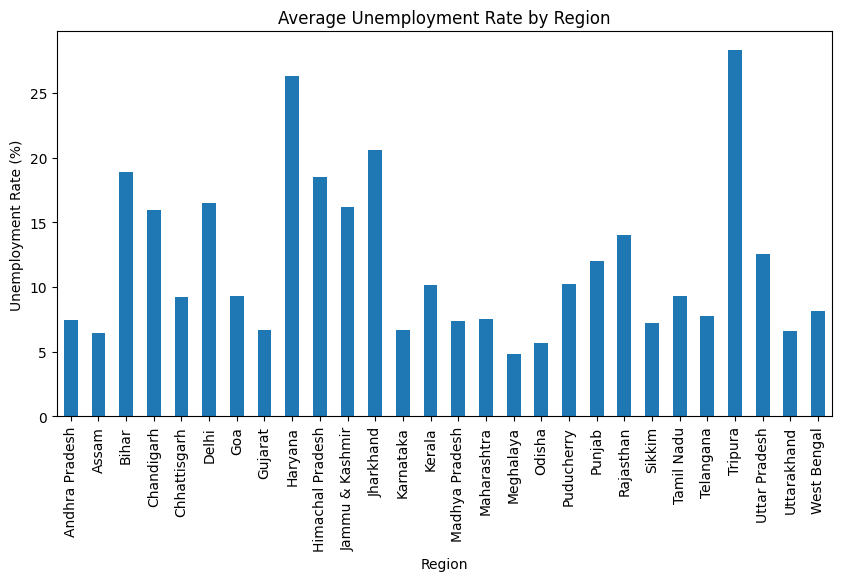

In [16]:
region = data.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

region.plot(kind="bar", figsize=(10,5))

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")

plt.show()

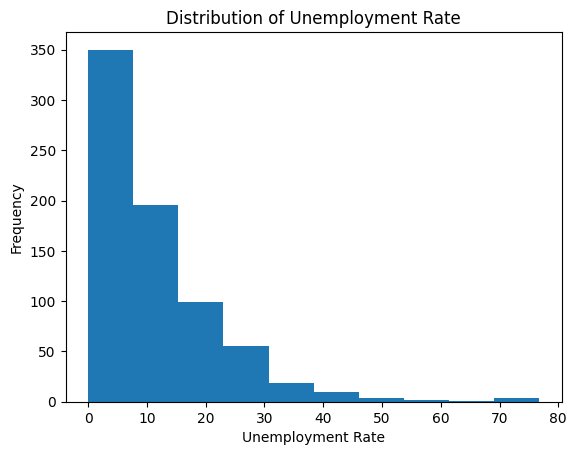

In [17]:
plt.hist(data["Estimated Unemployment Rate (%)"])

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate")
plt.ylabel("Frequency")

plt.show()

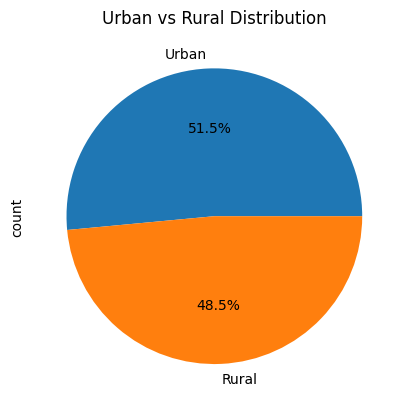

In [18]:
data["Area"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Urban vs Rural Distribution")

plt.show()

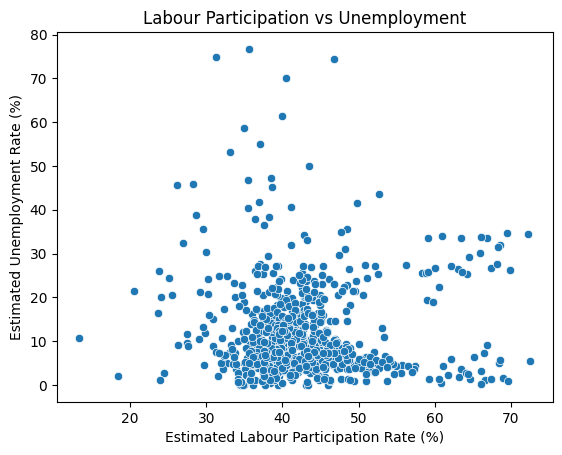

In [19]:
sns.scatterplot(
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)",
    data=data
)

plt.title("Labour Participation vs Unemployment")

plt.show()

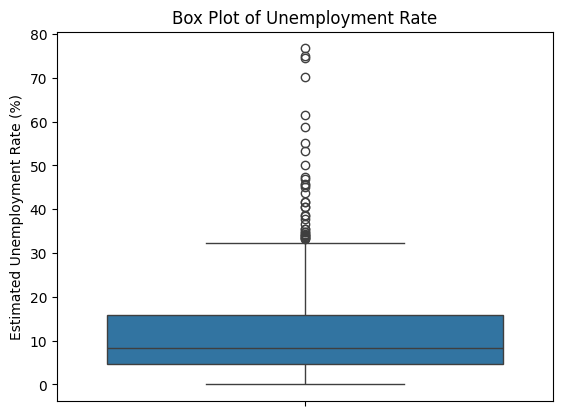

In [20]:
sns.boxplot(y="Estimated Unemployment Rate (%)", data=data)

plt.title("Box Plot of Unemployment Rate")

plt.show()

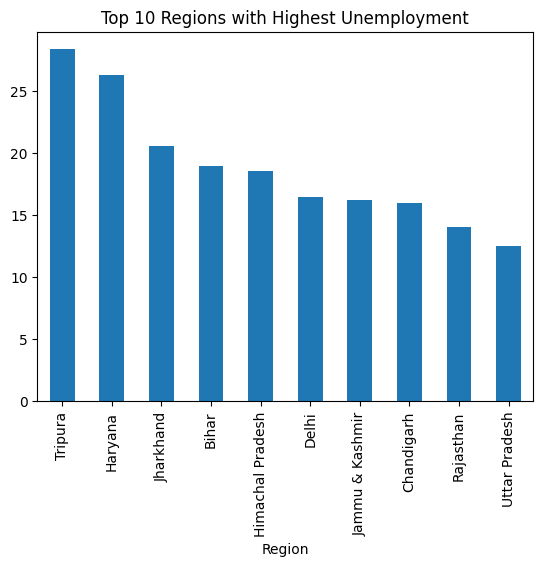

In [21]:
top = data.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

top.plot(kind="bar")

plt.title("Top 10 Regions with Highest Unemployment")

plt.show()

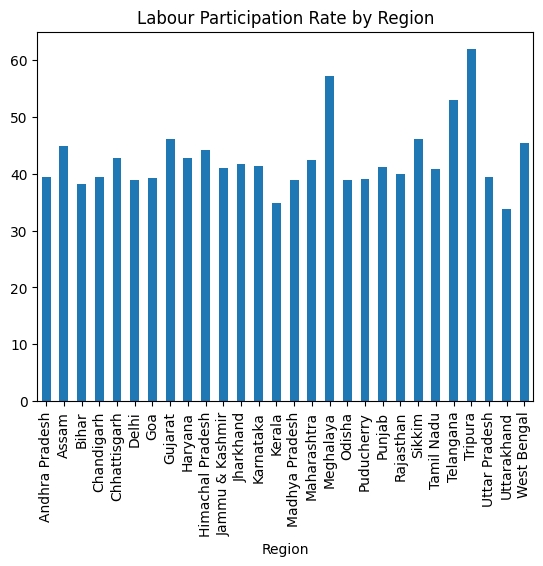

In [22]:
labour = data.groupby("Region")["Estimated Labour Participation Rate (%)"].mean()

labour.plot(kind="bar")

plt.title("Labour Participation Rate by Region")

plt.show()

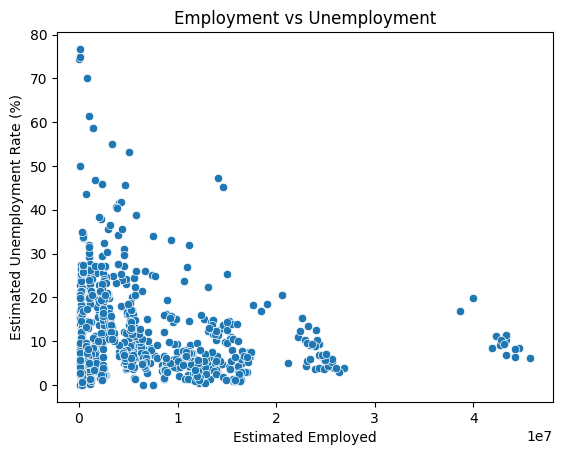

In [23]:
sns.scatterplot(
    x="Estimated Employed",
    y="Estimated Unemployment Rate (%)",
    data=data
)

plt.title("Employment vs Unemployment")

plt.show()

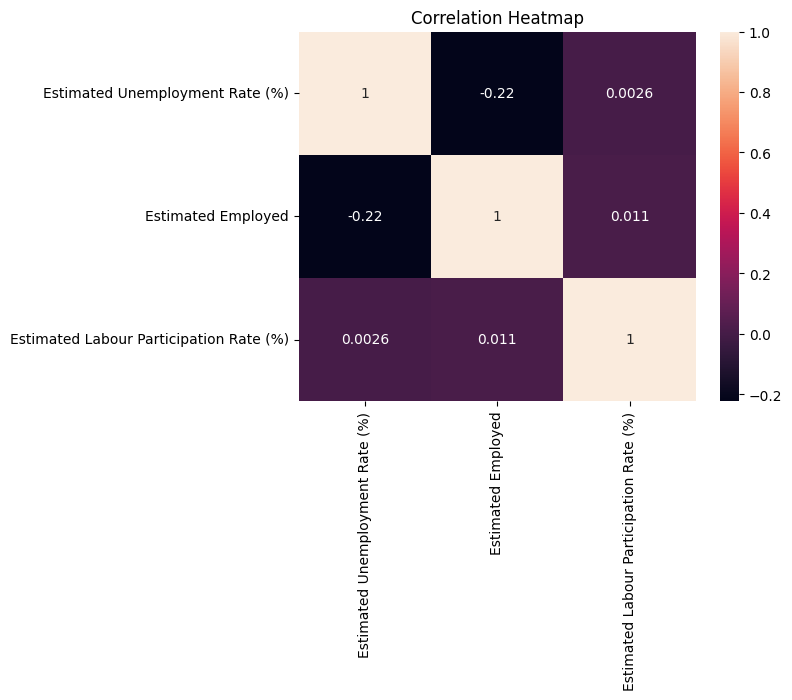

In [24]:
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

C:\Users\devik\AppData\Local\Temp\ipykernel_21736\3371003533.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["Date"] = pd.to_datetime(data["Date"])


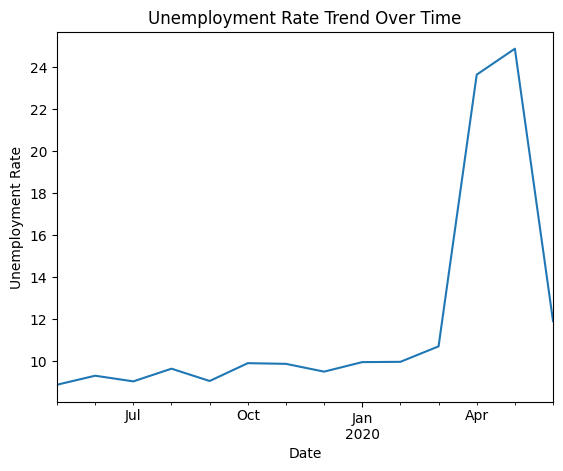

In [25]:
data["Date"] = pd.to_datetime(data["Date"])

trend = data.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

trend.plot()

plt.title("Unemployment Rate Trend Over Time")

plt.xlabel("Date")
plt.ylabel("Unemployment Rate")

plt.show()

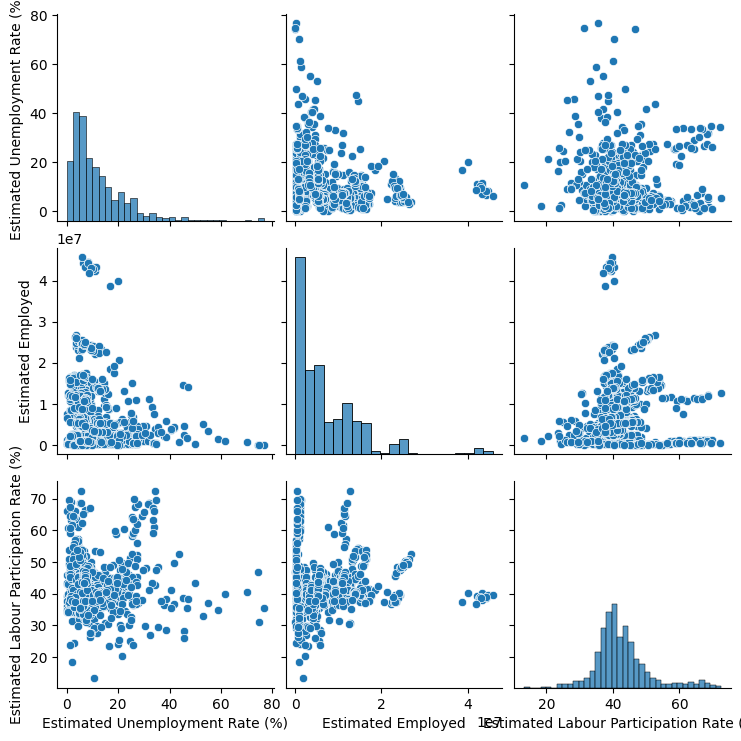

In [26]:
sns.pairplot(data)

plt.show()

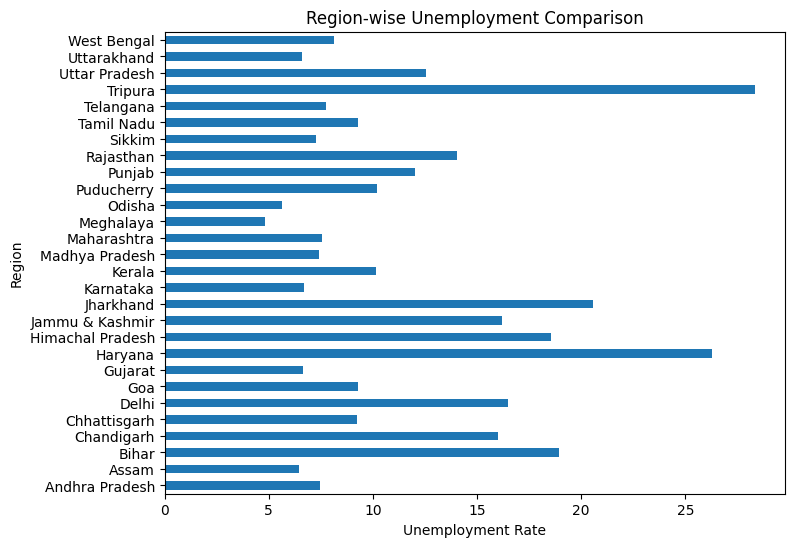

In [27]:
region.plot(kind="barh", figsize=(8,6))

plt.title("Region-wise Unemployment Comparison")

plt.xlabel("Unemployment Rate")

plt.show()